## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import grangercausalitytests

## Data Preprocessing

In [2]:
df = pd.read_csv('/Users/morenomusadat/Proyek Predictive Analytics/Price/Indonesia.csv', delimiter=";")
df.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Perubahan%,No
0,01/12/24,"16.090,0","15.870,0","16.322,5","15.830,0","1,58%",120
1,01/11/24,"15.840,0","15.705,0","15.971,5","15.617,5","0,96%",119
2,01/10/24,"15.690,0","15.175,0","15.778,5","15.167,5","3,67%",118
3,01/09/24,"15.135,0","15.497,5","15.583,5","15.065,0","-2,04%",117
4,01/08/24,"15.450,0","16.255,0","16.281,5","15.295,0","-4,95%",116


In [3]:
selected_columns = ["Tanggal", "Terakhir", "Tertinggi", "Terendah"]
df_selected = df[selected_columns]

df_selected.head()

,Tanggal,Terakhir,Tertinggi,Terendah
0,01/12/24,"16.090,0","16.322,5","15.830,0"
1,01/11/24,"15.840,0","15.971,5","15.617,5"
2,01/10/24,"15.690,0","15.778,5","15.167,5"
3,01/09/24,"15.135,0","15.583,5","15.065,0"
4,01/08/24,"15.450,0","16.281,5","15.295,0"


In [4]:
print(df_selected.dtypes)

Tanggal      object
Terakhir     object
Tertinggi    object
Terendah     object
dtype: object


In [5]:
for col in ['Terakhir', 'Tertinggi', 'Terendah']:
    df_selected[col] = df_selected[col].str.replace('.', '', regex=False)
    df_selected[col] = df_selected[col].str.replace(',', '.', regex=False)
    df_selected[col] = df_selected[col].astype(float)


df_selected['Tanggal'] = pd.to_datetime(df_selected['Tanggal'], format='%d/%m/%y')

/var/folders/0t/tym83fts64b5fv862t1vq5lm0000gn/T/ipykernel_35943/3812410038.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[col] = df_selected[col].str.replace('.', '', regex=False)
/var/folders/0t/tym83fts64b5fv862t1vq5lm0000gn/T/ipykernel_35943/3812410038.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[col] = df_selected[col].str.replace(',', '.', regex=False)
/var/folders/0t/tym83fts64b5fv862t1vq5lm0000gn/T/ipykernel_35943/3812410038.py:4: SettingWithCopyWarning: 
A value 

In [6]:
print(df_selected.dtypes)

Tanggal      datetime64[ns]
Terakhir            float64
Tertinggi           float64
Terendah            float64
dtype: object


## Grager Test

In [7]:
maxlag = 3
variables = ['Terakhir', 'Tertinggi', 'Terendah']
# Test for each pair: does "cause" Granger-cause "effect"?
for cause in variables:
    for effect in variables:
        if cause != effect:
            data_for_granger = df_selected[[effect, cause]].dropna()
            print(f"\nGranger causality test: Does '{cause}' cause '{effect}'?")
            grangercausalitytests(data_for_granger, maxlag=maxlag, verbose=True)


Granger causality test: Does 'Terakhir' cause 'Tertinggi'?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.7227  , p=0.0064  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=7.9224  , p=0.0049  , df=1
likelihood ratio test: chi2=7.6699  , p=0.0056  , df=1
parameter F test:         F=7.7227  , p=0.0064  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=11.1901 , p=0.0000  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=23.3704 , p=0.0000  , df=2
likelihood ratio test: chi2=21.3225 , p=0.0000  , df=2
parameter F test:         F=11.1901 , p=0.0000  , df_denom=113, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.7187  , p=0.0136  , df_denom=110, df_num=3
ssr based chi2 test:   chi2=11.8660 , p=0.0079  , df=3
likelihood ratio test: chi2=11.3021 , p=0.0102  , df=3
parameter F test:         F=3.7187  , p=0.0136  , df_denom=110, df_num=3

Granger causality test: Does 'Ter

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since function

## Feature Engineering

In [8]:
lags = 3
for lag in range(1, lags + 1):
    df_selected[f'Terakhir_lag_{lag}'] = df_selected['Terakhir'].shift(lag)
    df_selected[f'Tertinggi_lag_{lag}'] = df_selected['Tertinggi'].shift(lag)
    df_selected[f'Terendah_lag_{lag}'] = df_selected['Terendah'].shift(lag)

# Remove the rows with missing values due to shifting
df_selected.dropna(inplace=True)

# Set the date as the index for time series operations
df_selected.set_index('Tanggal', inplace=True)
print(df_selected.head())

            Terakhir  Tertinggi  Terendah  Terakhir_lag_1  Tertinggi_lag_1  \
Tanggal                                                                      
2024-09-01   15135.0    15583.5   15065.0         15690.0          15778.5   
2024-08-01   15450.0    16281.5   15295.0         15135.0          15583.5   
2024-07-01   16255.0    16427.5   16096.0         15450.0          16281.5   
2024-06-01   16370.0    16482.5   16190.0         16255.0          16427.5   
2024-05-01   16245.0    16275.0   15912.5         16370.0          16482.5   

            Terendah_lag_1  Terakhir_lag_2  Tertinggi_lag_2  Terendah_lag_2  \
Tanggal                                                                       
2024-09-01         15167.5         15840.0          15971.5         15617.5   
2024-08-01         15065.0         15690.0          15778.5         15167.5   
2024-07-01         15295.0         15135.0          15583.5         15065.0   
2024-06-01         16096.0         15450.0          16281.

/var/folders/0t/tym83fts64b5fv862t1vq5lm0000gn/T/ipykernel_35943/1308610533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[f'Terakhir_lag_{lag}'] = df_selected['Terakhir'].shift(lag)
/var/folders/0t/tym83fts64b5fv862t1vq5lm0000gn/T/ipykernel_35943/1308610533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected[f'Tertinggi_lag_{lag}'] = df_selected['Tertinggi'].shift(lag)


# Random Forest

## Split Data into Training and Testing Sets

In [9]:
train_size = int(0.8 * len(df_selected))
train = df_selected.iloc[:train_size]
test = df_selected.iloc[train_size:]

feature_cols = []
lags = 3 
for lag in range(1, lags + 1):
    feature_cols.extend([f'Terakhir_lag_{lag}', f'Tertinggi_lag_{lag}', f'Terendah_lag_{lag}'])

X_train = train[feature_cols]
y_train = train['Terakhir']
X_test = test[feature_cols]
y_test = test['Terakhir']

## Prediction

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error on Test Set:", mse)

Mean Squared Error on Test Set: 113418.53086249996


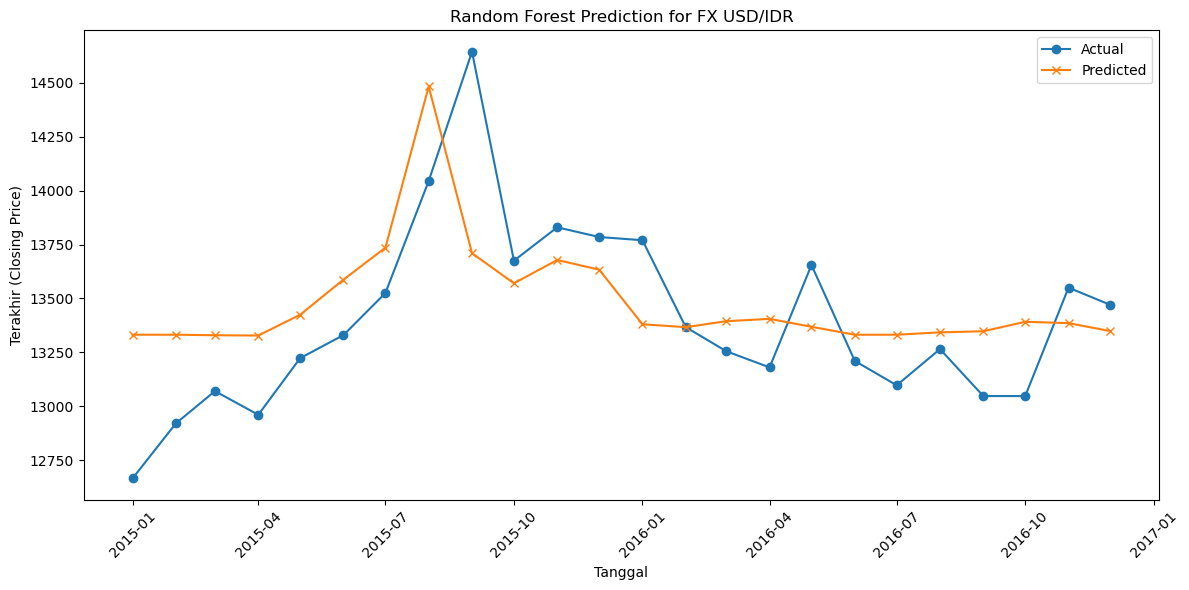

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label='Actual', marker='o')
plt.plot(test.index, y_pred, label='Predicted', marker='x')
plt.xlabel("Tanggal")
plt.ylabel("Terakhir (Closing Price)")
plt.title("Random Forest Prediction for FX USD/IDR")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation: 

Dapat dilihat bahwa Model tampaknya "meratakan" prediksi, yang berarti model kesulitan menangkap pergerakan tiba-tiba dan tajam dalam data (misalnya, lonjakan sekitar pertengahan 2015). Meskipun model cukup baik dalam memprediksi tren umum, model ini kesulitan untuk secara akurat menangkap pergerakan tajam dalam nilai tukar

# XGBoost

In [13]:
feature_cols = []
for var in variables:
    for lag in range(1, lags+1):
        feature_cols.append(f"{var}_lag_{lag}")

# Define target columns
target_cols = variables

X = df_selected[feature_cols]
y = df_selected[target_cols]

In [16]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42))
model.fit(X, y)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...))

In [19]:
last_date = df_selected.index[-1]
last_row = df_selected.iloc[-1]
current_features = last_row[feature_cols].values  # initial feature vector

max_horizon = 6
forecast_results = []  # list to store predictions for each step

for step in range(max_horizon):
    # Predict next month values for all three target variables
    prediction = model.predict(current_features.reshape(1, -1))[0]
    forecast_results.append(prediction)
    
    # Update lag features: for each variable, the new lag vector is the latest prediction followed by the previous lags (dropping the oldest)
    new_features = []
    start = 0
    for var in variables:
        current_lags = current_features[start:start+lags]
        # New first lag is the newly predicted value for this variable;
        # remaining lags are the previous lags shifted by one position.
        updated_lags = [prediction[variables.index(var)]] + list(current_lags[:-1])
        new_features.extend(updated_lags)
        start += lags
    current_features = np.array(new_features)

# Build a DataFrame for forecasted values using future dates
forecast_dates = [last_date + pd.DateOffset(months=i+1) for i in range(max_horizon)]
forecast_df = pd.DataFrame(forecast_results, index=forecast_dates, columns=target_cols)
print("\nForecasted Values (6 months ahead):")
print(forecast_df)


Forecasted Values (6 months ahead):
                Terakhir     Tertinggi      Terendah
2015-02-01  12665.036133  12757.530273  12410.029297
2015-03-01  12671.815430  12799.731445  12413.731445
2015-04-01  12671.815430  12799.555664  12411.055664
2015-05-01  12671.815430  12799.555664  12411.055664
2015-06-01  12671.815430  12799.555664  12411.055664
2015-07-01  12671.815430  12799.555664  12411.055664


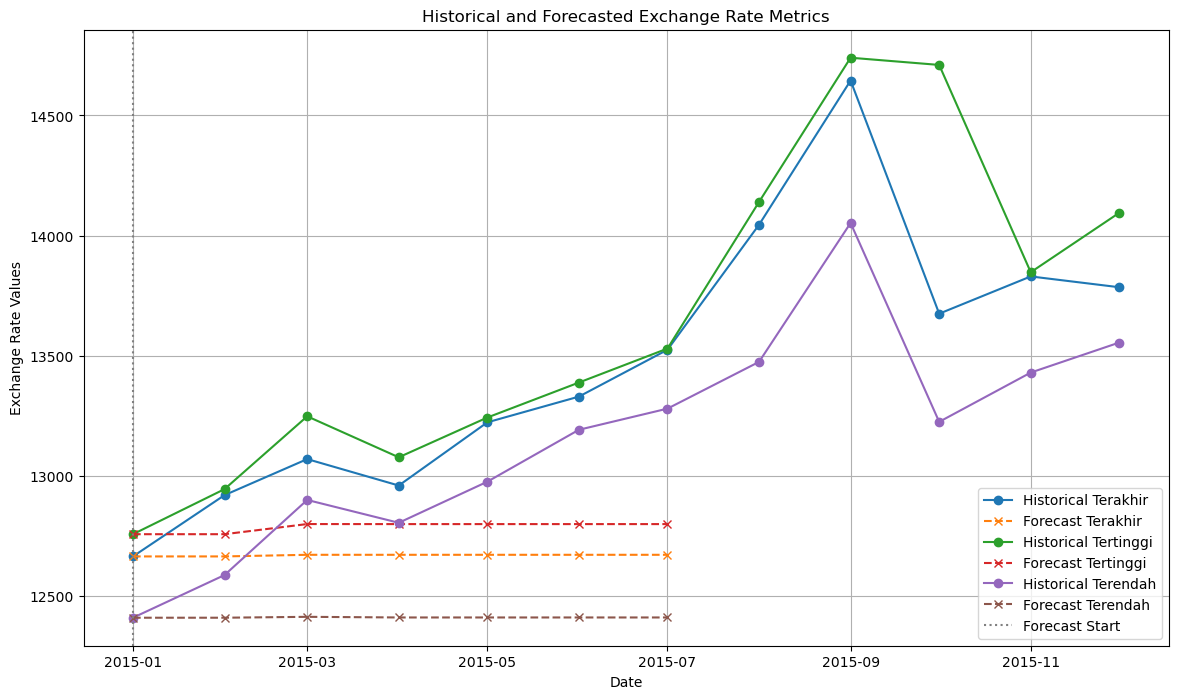

In [21]:
hist_dates = df_selected.index[-12:]
hist_start_date = hist_dates[0]

plt.figure(figsize=(14, 8))

# For each target variable, plot historical data and then forecast as a continuous extension.
for col in target_cols:
    # Extract historical data for the selected period.
    hist_series = df_selected[col].loc[hist_start_date:]
    # Create a combined series that starts with the historical data and continues with forecasted values.
    # To ensure continuity, we prepend the last historical value to the forecast series.
    forecast_series = forecast_df[col]
    forecast_line = pd.concat([pd.Series({hist_series.index[-1]: hist_series.values[-1]}), forecast_series])
    
    # Plot historical part as a solid line.
    plt.plot(hist_series.index, hist_series.values, marker='o', label=f'Historical {col}')
    # Plot forecasted part as a dashed line.
    plt.plot(forecast_line.index, forecast_line.values, linestyle='--', marker='x', label=f'Forecast {col}')

# Optionally, mark the boundary between historical and forecasted data.
plt.axvline(x=last_date, color='gray', linestyle=':', label='Forecast Start')

plt.xlabel('Date')
plt.ylabel('Exchange Rate Values')
plt.title('Historical and Forecasted Exchange Rate Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Vector Autoregression Model